Test the perturbed slab model created.

In [2]:
import numpy as np
from slab_bfield_one_pert import SlabBfieldOnePert
from pyoculus.maps import ToroidalBfieldSection
from pyoculus.solvers import PoincarePlot, FixedPoint
import matplotlib.pyplot as plt

#### Create the magnetic field:

In [3]:
field = SlabBfieldOnePert(
    m=2,
    n=0,
    delta=0.01,
    iota_prime=1.0,
    x0=0.5,
)

coords = np.array([0.4, 0.2, 0.3])

print("B:")
print(field.B(coords))

print("\nB and dBdX:")
B, dBdX = field.dBdX(coords)

print(B)
print(dBdX)

print("The island will be situated at x_s =", field.x0 + field.n / (field.iota_prime * field.m))

B:
[ 0.00186921 -0.09815788  1.        ]

B and dBdX:
[ 0.00186921 -0.09815788  1.        ]
[[ 0.00155767  0.00884219  0.        ]
 [ 0.98157878 -0.00155767  0.        ]
 [ 0.          0.          0.        ]]
The island will be situated at x_s = 0.5


#### Create the map:

In [4]:
map = ToroidalBfieldSection(field)

In [5]:
x0 = np.array([0.4, 0.2])
x1 = map.f(1, x0)
x2 = map.f(1, x1)

print("Initial point:")
print(x0)

print("After one map iteration:")
print(x1)

print("After two map iterations:")
print(x2)

Initial point:
[0.4 0.2]
After one map iteration:
[0.39410824 5.86606102]
After two map iterations:
[0.36719957 5.11581684]


#### Create Poincaré plot:

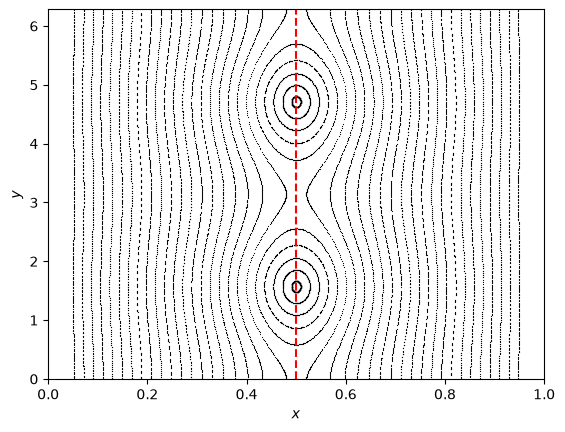

In [6]:
pplot = PoincarePlot.with_segments(
    map,
    np.array([
        [0.05, np.pi / 2],
        [0.95, np.pi / 2],
        [0.05, 3 * np.pi / 2],
        [0.95, 3 * np.pi / 2],
    ]),
    neps=[50, 50],
    connected=False,
)

# Follow each initial condition for 200 crossings
pplot.compute(npts=150)

# Plot directly in (x,y) coordinates
fig, ax = pplot.plot(plottype=None) # plottypeNone to directly plot in the coordinates of the map

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_xlim(0, 1)
ax.set_ylim(0, 2*np.pi)

xs = field.x0 + field.n / (field.iota_prime * field.m)

ax.axvline(
    xs,
    linestyle="--",
    label=rf"$x_s={xs:.3f}$",
    color="r"
)

plt.show()

#### Find fixed points:

In [7]:
# Find a t-periodic point
fp = FixedPoint(map)

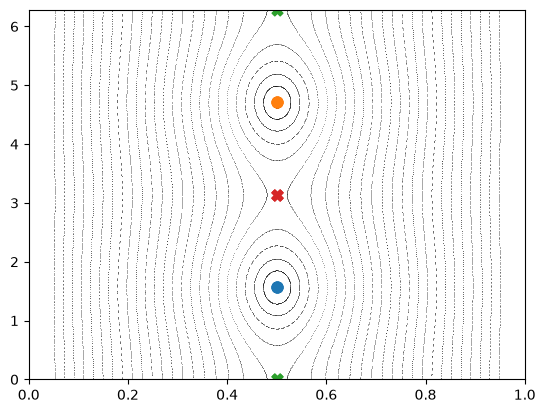

In [8]:
fig, ax = pplot.plot(
    marker=".",
    s=0.5,
    xlim=[0, 1.],
    ylim=[0, 2*np.pi],
    plottype=None
)


fp = FixedPoint(map)

# Elliptic FP / O-points:
result = fp.find_with_iota(
    n = field.n,
    m = field.m,
    guess = np.array([0.45, 1.3]),
    method="scipy.root"
)   

fp.plot(
    fig=fig,
    ax=ax,
    marker="o",
    s=60,
    plottype=None
)

result = fp.find_with_iota(
    n = field.n,
    m = field.m,
    guess = np.array([0.45, 4.5]),
    method="scipy.root"
)   

fp.plot(
    fig=fig,
    ax=ax,
    marker="o",
    s=60,
    plottype=None
)

# Hyperbolic FP / X-points:
result = fp.find_with_iota(
    n = field.n,
    m = field.m,
    guess = np.array([0.45, 0.5]),
    method="scipy.root"
)   

fp.plot(
    fig=fig,
    ax=ax,
    marker="X",
    s=60,
    plottype=None
)

result = fp.find_with_iota(
    n = field.n,
    m = field.m,
    guess = np.array([0.45, 3]),
    method="scipy.root"
)   

fp.plot(
    fig=fig,
    ax=ax,
    marker="X",
    s=60,
    plottype=None
)


plt.show()


#### Wrong cases:

```fp.find(t=t,...)``` doesn't always work: sometimes we stumble upon t-cycles that aren't fixed points.

[[0.5        6.28318531]
 [0.5        6.28318531]]
[[5.00000000e-01 1.77635684e-14]
 [5.00000000e-01 2.23434919e-14]
 [5.00000000e-01 3.54880897e-14]]
[[0.16652463 5.50342181]
 [0.17024208 3.38506276]
 [0.16303324 1.28985923]
 [0.16652463 5.50342181]]


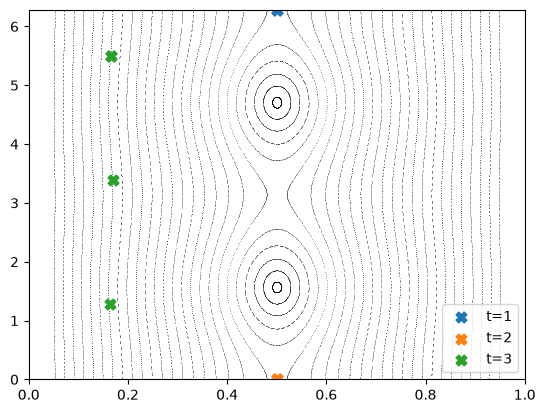

In [9]:
guess = np.array([0.45, 6])
fig, ax = pplot.plot(
    marker=".",
    s=0.5,
    xlim=[0, 1.],
    ylim=[0, 2*np.pi],
    plottype=None
)

for t in [1,2,3]:
    fp = FixedPoint(map)
    result = fp.find(
        t=t,                    # t-order fixed points
        guess=guess,
        method="scipy.root"
    ) 
    print(result.coords)     

    fp.plot(
        fig=fig,
        ax=ax,
        marker="X",
        s=60,
        label=f"t={t}",
        plottype=None
    )

plt.legend(loc="lower right")
plt.show()
